In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

In [16]:
face_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(root='Data', transform=face_transform)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

In [17]:
class BetaVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(BetaVAE, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), # 32*24*24
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),# 64*12*12
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),# 128*6*6
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),# 256*3*3
            nn.ReLU(),
            nn.Flatten() # 256*3*3 = 2304
        )

        # Latent Space: Linear layers for Mean and Log-Variance
        self.fc_mu = nn.Linear(2304, latent_dim)
        self.fc_var = nn.Linear(2304, latent_dim)

        # Decoder: Linear to expand latent dim, then ConvTranspose to 48x48
        self.decoder_input = nn.Linear(latent_dim, 2304)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1), # 128*6*6
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 64*12*12
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),  # 32*24*24
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1), # 1*48*48
            nn.Sigmoid()
        )



    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        features = self.encoder(x)
        mu = self.fc_mu(features)
        logvar = self.fc_var(features)

        z = self.reparameterize(mu,logvar)

        x_hat = self.decoder_input(z)
        x_hat = x_hat.view(-1,256,3,3)
        reconstruction = self.decoder(x_hat)

        return reconstruction, mu, logvar

In [18]:
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.l1_loss(recon_x, x, reduction='sum')
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kld_loss

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = BetaVAE(latent_dim=16).to(device)

model.load_state_dict(torch.load('beta_vae_weights0_3.pth', map_location=device))
model.eval()

BetaVAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=2304, out_features=16, bias=True)
  (fc_var): Linear(in_features=2304, out_features=16, bias=True)
  (decoder_input): Linear(in_features=16, out_features=2304, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(

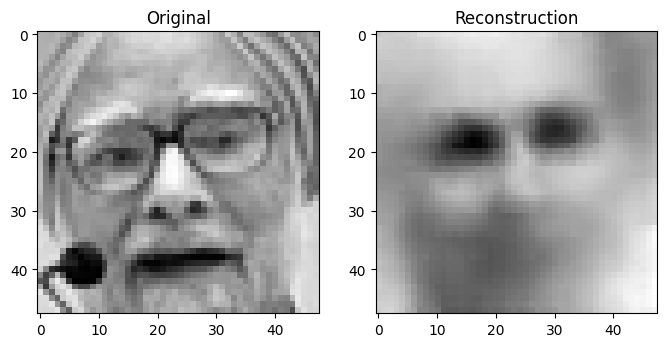

In [20]:
from PIL import Image

def predict_single_image(image_path, model):
    # Load and transform the image
    img = Image.open(image_path)
    img_tensor = face_transform(img).unsqueeze(0).to(device) # Add batch dimension
    
    with torch.no_grad():
        # Get the reconstruction from the VAE
        reconstruction, mu, logvar = model(img_tensor)
        
    return img_tensor, reconstruction

# Example usage:
# original, recovered = predict_single_image('path_to_test_img.jpg', model)

import matplotlib.pyplot as plt

def show_results(original, reconstructed):
    original = original.squeeze().cpu().numpy()
    reconstructed = reconstructed.squeeze().cpu().numpy()
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Original")
    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title("Reconstruction")
    plt.show()

# Run the test
orig, recon = predict_single_image('Data/all/1.png', model)
show_results(orig, recon)

In [21]:
import torch
import onnx 

model.eval()
decoder_input = torch.randn(1,16)

# We only need the decoder layers for the frontend knobs
class DecoderOnly(torch.nn.Module):
    def __init__(self, full_model):
        super().__init__()
        self.decoder_input = full_model.decoder_input
        self.decoder = full_model.decoder

    def forward(self, z):
        x = self.decoder_input(z)
        x = x.view(-1, 256, 3, 3) # Reshape to match your conv layers
        return self.decoder(x)

decoder_model = DecoderOnly(model)

# 1. Export from PyTorch
torch.onnx.export(decoder_model, decoder_input, "decoder.onnx")

# 2. Force inline configuration to discard the external data requirement
inline_model = onnx.load("decoder.onnx")
onnx.save_model(inline_model, "decoder.onnx")


/tmp/ipykernel_13085/1378790016.py:22: UserWarning: Exporting a model while it is in training mode. Please ensure that this is intended, as it may lead to different behavior during inference. Calling model.eval() before export is recommended.
  torch.onnx.export(decoder_model, decoder_input, "decoder.onnx")
W0403 01:23:22.265000 13085 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0403 01:23:22.266000 13085 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0403 01:23:22.267000 13085 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size

[torch.onnx] Obtain model graph for `DecoderOnly([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DecoderOnly([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
